# Session 1b: Visual EDA
**Emission-trajectory ML project. Dr. Khawar Naeem, QTTSC, Qatar University.**

This notebook turns the Session 1 findings (`01_framing_eda.ipynb`) into figures. Every figure states one modeling consequence, because each of these plots is the visual argument for a decision already locked in the frozen problem statement.

Figures are saved to `../results/figures/` so the README can cite them as saved artifacts, per the project rule that every quantitative claim ties to a saved result.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/raw/owid-co2-data.csv")
is_country = df["iso_code"].notna() & ~df["iso_code"].astype(str).str.startswith("OWID")
countries = df[is_country].copy()
print(countries["country"].nunique(), "countries")

218 countries


## Figure 1. The skew: why the mean country does not exist

2023 emissions across countries, on a log x-axis. On a linear axis this histogram would be one bar near zero and a few invisible dots; the log scale is what makes a five-orders-of-magnitude variable readable.

The mean (172 Mt) sits far to the right of the median (10.5 Mt) because China, the US, and a few others drag it. **Modeling consequence:** overall MAE is dominated by giants, so the evaluation plan requires median errors, percentage errors, and emitter-size tiers.

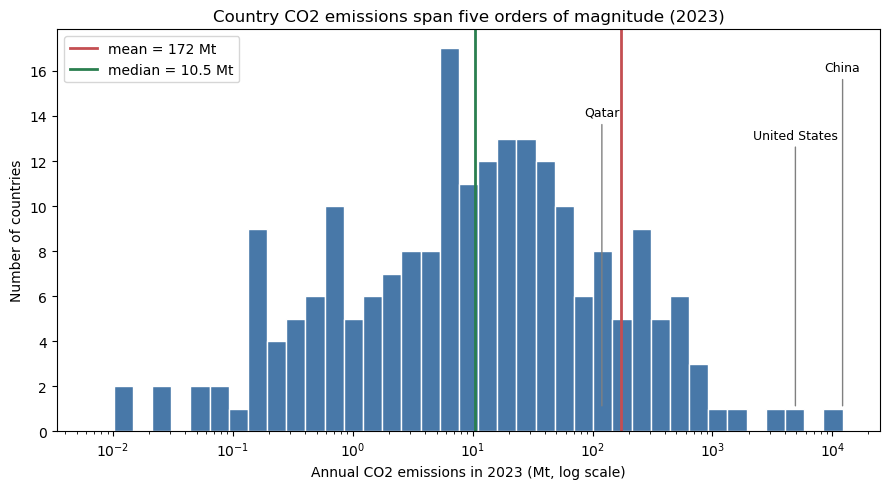

In [2]:
lvl = countries[(countries["year"] == 2023) & countries["co2"].notna()].set_index("country")["co2"]
pos = lvl[lvl > 0]

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 40)
ax.hist(pos, bins=bins, color="#4878a8", edgecolor="white")
ax.set_xscale("log")
ax.axvline(lvl.mean(), color="#c44e52", lw=2, label=f"mean = {lvl.mean():.0f} Mt")
ax.axvline(lvl.median(), color="#2a7f4f", lw=2, label=f"median = {lvl.median():.1f} Mt")
label_heights = {"China": 16, "United States": 13, "Qatar": 14}
for name, h in label_heights.items():
    ax.annotate(name, xy=(lvl[name], 1), xytext=(lvl[name], h),
                ha="center", fontsize=9, arrowprops=dict(arrowstyle="-", color="gray"))
ax.set_xlabel("Annual CO2 emissions in 2023 (Mt, log scale)")
ax.set_ylabel("Number of countries")
ax.set_title("Country CO2 emissions span five orders of magnitude (2023)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_distribution_skew.png", dpi=150)
plt.show()

## Figure 2. Concentration: the top-5 problem

Top-10 emitters in 2023 with each country's share of the world total. The top 5 alone are 62%. **Modeling consequence:** a model that only fits China and the US well can look excellent on overall MAE while being useless for the median country; size-tier reporting catches this.

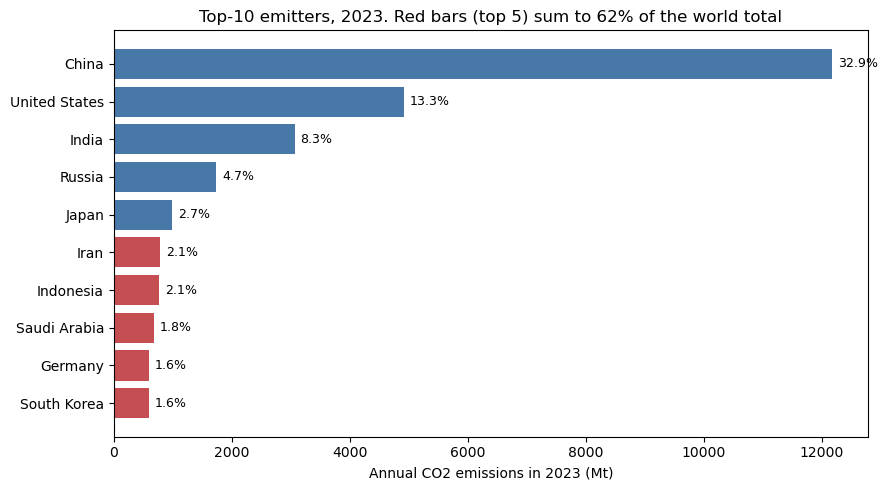

In [3]:
top10 = lvl.nlargest(10)
share = top10 / lvl.sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10.index[::-1], top10[::-1], color=["#c44e52" if i >= 5 else "#4878a8" for i in range(9, -1, -1)])
for name, val in top10.items():
    ax.text(val + 100, name, f"{share[name]:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Annual CO2 emissions in 2023 (Mt)")
ax.set_title("Top-10 emitters, 2023. Red bars (top 5) sum to 62% of the world total")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_top10_concentration.png", dpi=150)
plt.show()

## Figure 3. Persistence: the baseline to beat

Distribution of the absolute year-over-year change as a percentage of the level, all country-years since 2010. Half of all country-years move less than 4.4%. **Modeling consequence:** "predict last year's value" is already a strong forecast; every model is scored with a skill score against it.

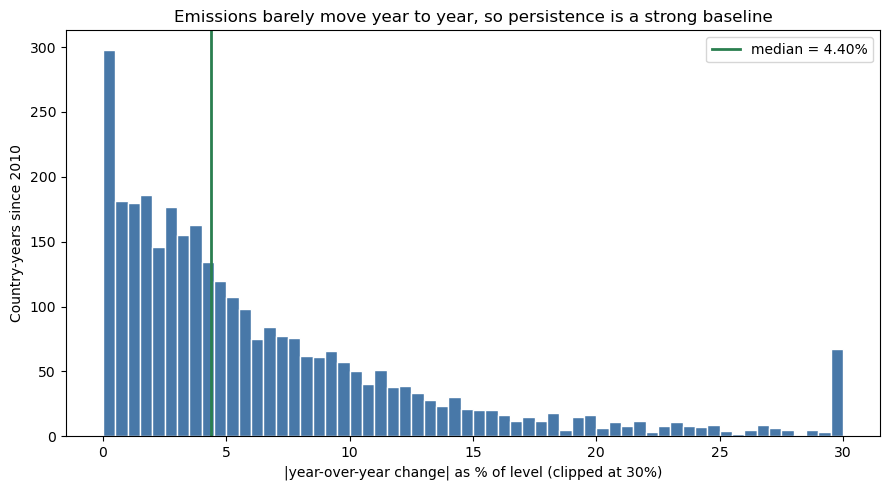

In [4]:
c = countries.sort_values(["country", "year"]).copy()
c["yoy_change"] = c.groupby("country")["co2"].diff()
recent = c[(c["year"] >= 2010) & c["yoy_change"].notna() & (c["co2"] > 0)]
rel = (recent["yoy_change"].abs() / recent["co2"]) * 100
med = rel.median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(rel.clip(upper=30), bins=60, color="#4878a8", edgecolor="white")
ax.axvline(med, color="#2a7f4f", lw=2, label=f"median = {med:.2f}%")
ax.set_xlabel("|year-over-year change| as % of level (clipped at 30%)")
ax.set_ylabel("Country-years since 2010")
ax.set_title("Emissions barely move year to year, so persistence is a strong baseline")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_persistence_yoy.png", dpi=150)
plt.show()

## Figure 4. Missingness: the two-wave feature map

Percent missing per candidate feature column (country rows, 1990+), now including the energy family. Green = Wave 1 (use now, drop the few missing rows). Orange = Wave 2 (needs explicit missing-data handling). **Modeling consequence:** feature choice here is a data-quality decision made before any model exists.

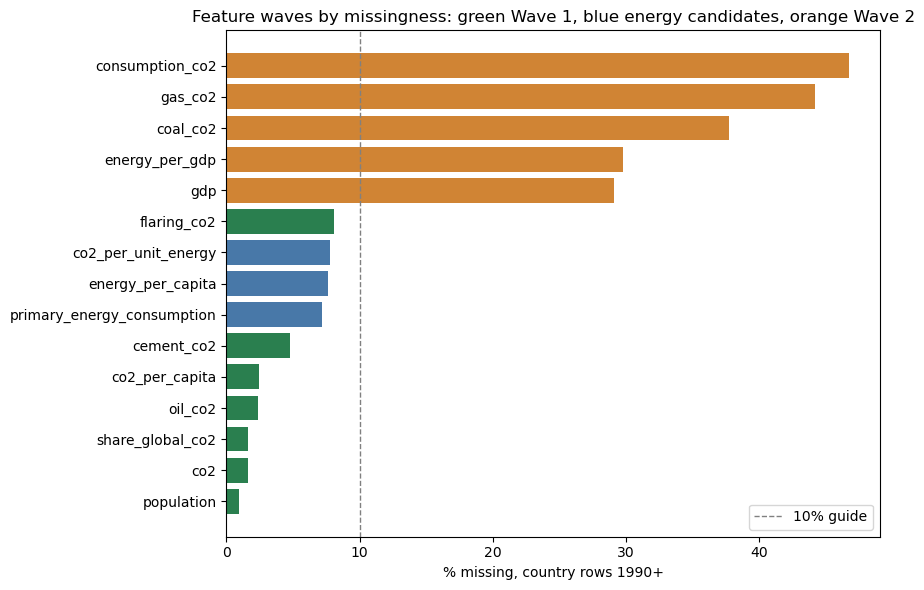

In [5]:
modern = countries[countries["year"] >= 1990]
wave1 = ["population", "co2", "share_global_co2", "oil_co2", "co2_per_capita", "cement_co2", "flaring_co2"]
wave2 = ["gdp", "coal_co2", "gas_co2", "consumption_co2", "energy_per_gdp"]
energy_candidates = ["primary_energy_consumption", "energy_per_capita", "co2_per_unit_energy"]
cols = wave1 + energy_candidates + wave2
miss = modern[cols].isna().mean().mul(100).sort_values()

def color(col):
    if col in wave1:
        return "#2a7f4f"
    if col in energy_candidates:
        return "#4878a8"
    return "#d08434"

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(miss.index, miss.values, color=[color(x) for x in miss.index])
ax.axvline(10, color="gray", ls="--", lw=1, label="10% guide")
ax.set_xlabel("% missing, country rows 1990+")
ax.set_title("Feature waves by missingness: green Wave 1, blue energy candidates, orange Wave 2")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_missingness_waves.png", dpi=150)
plt.show()

## Figure 5. Energy and emissions move together

Primary energy consumption vs. CO2 emissions, 2023, log-log. The near-linear cloud shows how tightly national emissions track national energy use; countries below the trend burn cleaner energy per unit (more renewables, nuclear, gas instead of coal). **Modeling consequence:** energy columns (7-8% missing) are strong feature candidates for the CO2 model. Predicting energy itself is a gated extension after the CO2 model ships, since the pipeline is target-agnostic.

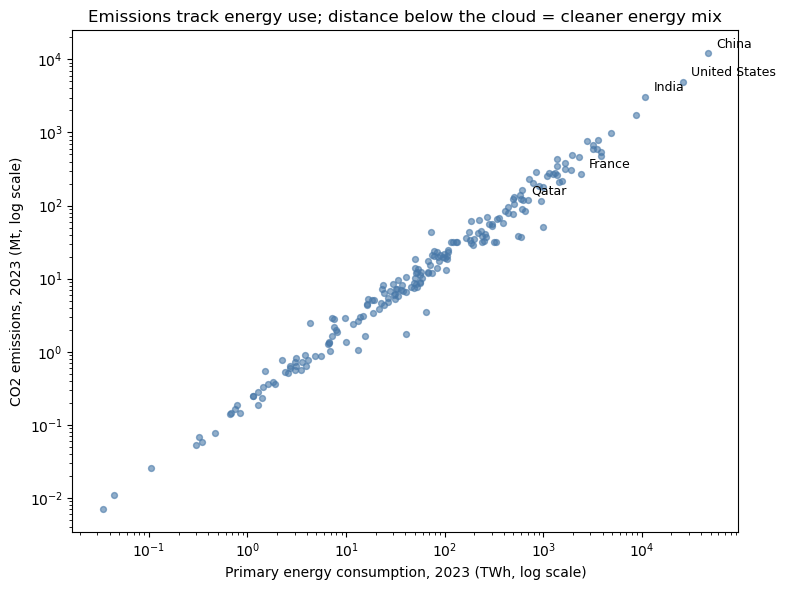

In [6]:
snap = countries[(countries["year"] == 2023) & countries["co2"].notna() & countries["primary_energy_consumption"].notna()]
snap = snap[(snap["co2"] > 0) & (snap["primary_energy_consumption"] > 0)]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(snap["primary_energy_consumption"], snap["co2"], s=18, alpha=0.6, color="#4878a8")
for name in ["China", "United States", "Qatar", "France", "India"]:
    row = snap[snap["country"] == name]
    if len(row):
        ax.annotate(name, (row["primary_energy_consumption"].iloc[0], row["co2"].iloc[0]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Primary energy consumption, 2023 (TWh, log scale)")
ax.set_ylabel("CO2 emissions, 2023 (Mt, log scale)")
ax.set_title("Emissions track energy use; distance below the cloud = cleaner energy mix")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_energy_vs_co2.png", dpi=150)
plt.show()

## Figure 6. The sanity anchor: Qatar

Qatar's CO2 trajectory since 1990, with the 2020 COVID-era dip marked. This is the series used to hand-verify the Session 2 target shift (the 2023 row must carry 2024's value, 125.8 Mt, as its target). **Modeling consequence:** one country you know well, checked by eye, catches off-by-one shift bugs that metrics never will.

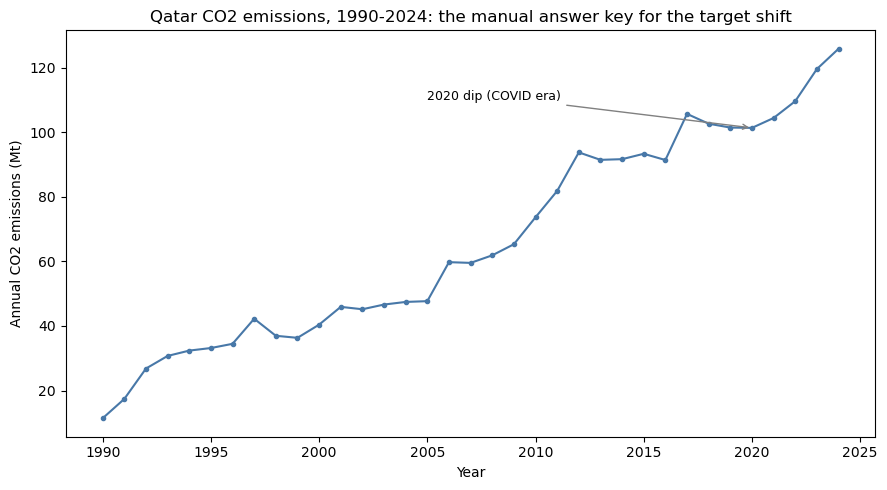

In [7]:
qat = countries[(countries["country"] == "Qatar") & (countries["year"] >= 1990)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(qat["year"], qat["co2"], marker="o", ms=3, color="#4878a8")
dip = qat[qat["year"] == 2020]
ax.annotate("2020 dip (COVID era)", xy=(2020, dip["co2"].iloc[0]),
            xytext=(2005, 110), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("Year")
ax.set_ylabel("Annual CO2 emissions (Mt)")
ax.set_title("Qatar CO2 emissions, 1990-2024: the manual answer key for the target shift")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_qatar_anchor.png", dpi=150)
plt.show()

## Figure 7. The denominator changes the story: totals vs. per capita

Population vs. CO2 emissions, 2023, log-log, with diagonal reference lines of constant per-capita emissions. Countries on the same diagonal emit the same amount per person regardless of size. China and India sit high because they are populous; Qatar sits far above the cloud because each resident accounts for roughly 40 tonnes per year, the highest per-capita rate in the dataset, against a global average near 4.7.

**Modeling consequence:** the same data supports opposite rankings depending on the denominator (China leads totals, Qatar leads per capita). Neither framing is privileged, which is one more reason evaluation reports percentage and per-capita-aware errors rather than a single absolute number.

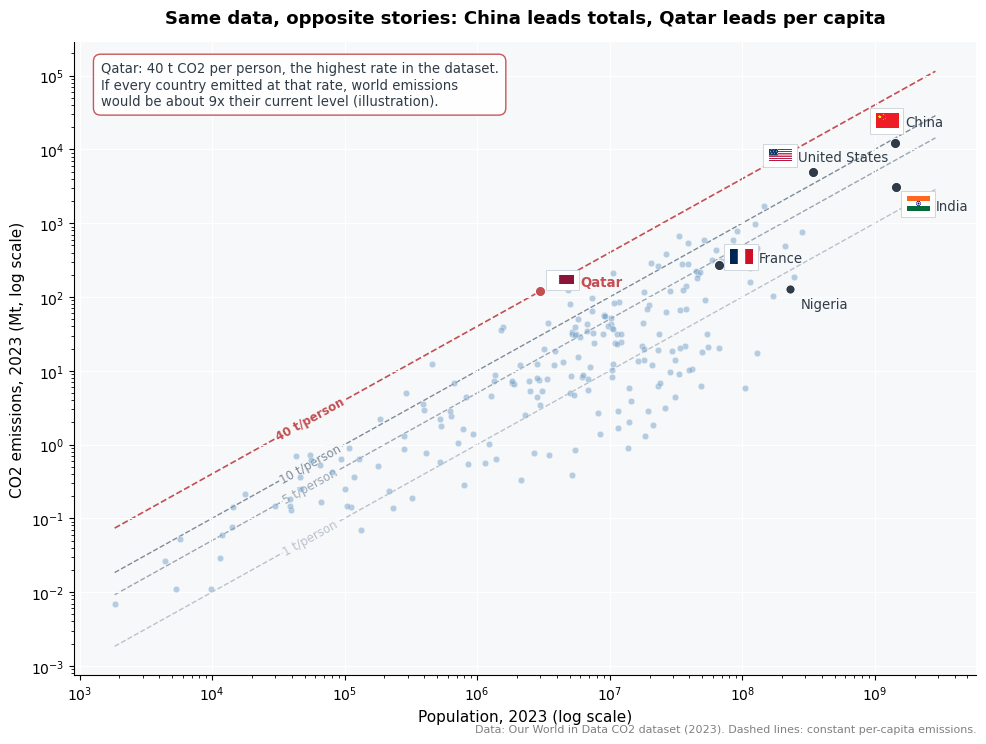

Qatar per capita: 40.1 t/person
World total 2023: 37003 Mt
World at Qatar's per-capita rate: 8.8x current


In [8]:
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

snap7 = countries[(countries["year"] == 2023) & countries["co2"].notna() & countries["population"].notna()]
snap7 = snap7[(snap7["co2"] > 0) & (snap7["population"] > 0)]

fig, ax = plt.subplots(figsize=(10, 7.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f7f8fa")

ax.scatter(snap7["population"], snap7["co2"], s=22, alpha=0.55, color="#7da7cc",
           edgecolor="white", linewidth=0.4, zorder=3)

# Diagonals of constant per-capita emissions: co2 [Mt] = population * tpc / 1e6
pmin, pmax = snap7["population"].min(), snap7["population"].max()
pop_range = np.logspace(np.log10(pmin), np.log10(pmax) + 0.3, 50)
label_x = pmin * 30  # place diagonal labels inside the axes, clear of the ticks
for tpc, shade in zip([1, 5, 10, 40], ["#b9c2cc", "#9aa6b3", "#7d8b9a", "#c44e52"]):
    ax.plot(pop_range, pop_range * tpc / 1e6, ls="--", lw=1.2 if tpc == 40 else 1,
            color=shade, zorder=1)
    ax.annotate(f"{tpc} t/person", xy=(label_x, label_x * tpc / 1e6), fontsize=8.5,
                color=shade, ha="center", va="center", rotation=29, zorder=2,
                fontweight="bold" if tpc == 40 else "normal",
                bbox=dict(boxstyle="round,pad=0.15", facecolor="#f7f8fa", edgecolor="none"))

# Highlighted countries with national flags placed right beside each dot
FLAG_DIR = Path("../assets/flags")
flags = {"Qatar": "qa", "China": "cn", "United States": "us", "India": "in", "France": "fr"}
label_offsets = {"Qatar": (16, 8), "China": (-6, 16), "United States": (-24, 12),
                 "India": (16, -12), "France": (16, 6)}
for name, code in flags.items():
    row = snap7[snap7["country"] == name]
    if not len(row):
        continue
    x, y = row["population"].iloc[0], row["co2"].iloc[0]
    ax.scatter([x], [y], s=55, color="#c44e52" if name == "Qatar" else "#2f3b47",
               zorder=4, edgecolor="white", linewidth=0.8)
    flag_path = FLAG_DIR / f"{code}.png"
    dx, dy = label_offsets[name]
    if flag_path.exists():
        ab = AnnotationBbox(OffsetImage(plt.imread(flag_path), zoom=0.2), (x, y),
                            xybox=(dx, dy), boxcoords="offset points", zorder=5,
                            frameon=True, bboxprops=dict(edgecolor="#c9d1d9", linewidth=0.6))
        ax.add_artist(ab)
        ax.annotate(name, (x, y), textcoords="offset points", xytext=(dx + 13, dy - 4),
                    fontsize=9.5, color="#c44e52" if name == "Qatar" else "#2f3b47",
                    fontweight="bold" if name == "Qatar" else "normal", ha="left")
    else:
        ax.annotate(name, (x, y), textcoords="offset points", xytext=(dx, dy), fontsize=9.5)

# Nigeria kept as a plain label (contrast case: 220M people, under 1 t/person)
row = snap7[snap7["country"] == "Nigeria"]
ax.scatter(row["population"], row["co2"], s=45, color="#2f3b47", zorder=4,
           edgecolor="white", linewidth=0.8)
ax.annotate("Nigeria", (row["population"].iloc[0], row["co2"].iloc[0]),
            textcoords="offset points", xytext=(8, -14), fontsize=9.5, color="#2f3b47")

# Insight box: the counterfactual, framed as an illustration
qtr = snap7[snap7["country"] == "Qatar"].iloc[0]
tpc_qatar = qtr["co2"] * 1e6 / qtr["population"]
world_ratio = (snap7["population"].sum() * tpc_qatar / 1e6) / snap7["co2"].sum()
ax.text(0.03, 0.97,
        f"Qatar: {tpc_qatar:.0f} t CO2 per person, the highest rate in the dataset.\n"
        f"If every country emitted at that rate, world emissions\n"
        f"would be about {world_ratio:.0f}x their current level (illustration).",
        transform=ax.transAxes, va="top", ha="left", fontsize=9.5, color="#2f3b47",
        bbox=dict(boxstyle="round,pad=0.55", facecolor="white", edgecolor="#c44e52", alpha=0.95))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Population, 2023 (log scale)", fontsize=11)
ax.set_ylabel("CO2 emissions, 2023 (Mt, log scale)", fontsize=11)
ax.set_title("Same data, opposite stories: China leads totals, Qatar leads per capita",
             fontsize=13, fontweight="bold", pad=14)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, which="major", color="white", lw=0.8, zorder=0)
ax.text(1.0, -0.09, "Data: Our World in Data CO2 dataset (2023). Dashed lines: constant per-capita emissions.",
        transform=ax.transAxes, ha="right", fontsize=8, color="gray")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig7_population_percapita.png", dpi=150, facecolor="white")
plt.show()

print(f"Qatar per capita: {tpc_qatar:.1f} t/person")
print(f"World total 2023: {snap7['co2'].sum():.0f} Mt")
print(f"World at Qatar's per-capita rate: {world_ratio:.1f}x current")

## Figure 8. The reversal, made explicit

Figure 7 shows the geometry; this figure makes the punchline unmissable. Two rankings from the same 2023 data (countries above 1 million population): total emissions on the left, per-person emissions on the right. Only two countries appear on both lists (Saudi Arabia and the United States). China leads the left panel and is absent from the right; Qatar leads the right panel and is absent from the left.

**Modeling consequence:** rankings are artifacts of the question asked. An evaluation that reports only one aggregate number makes the same mistake as reading only one of these panels.

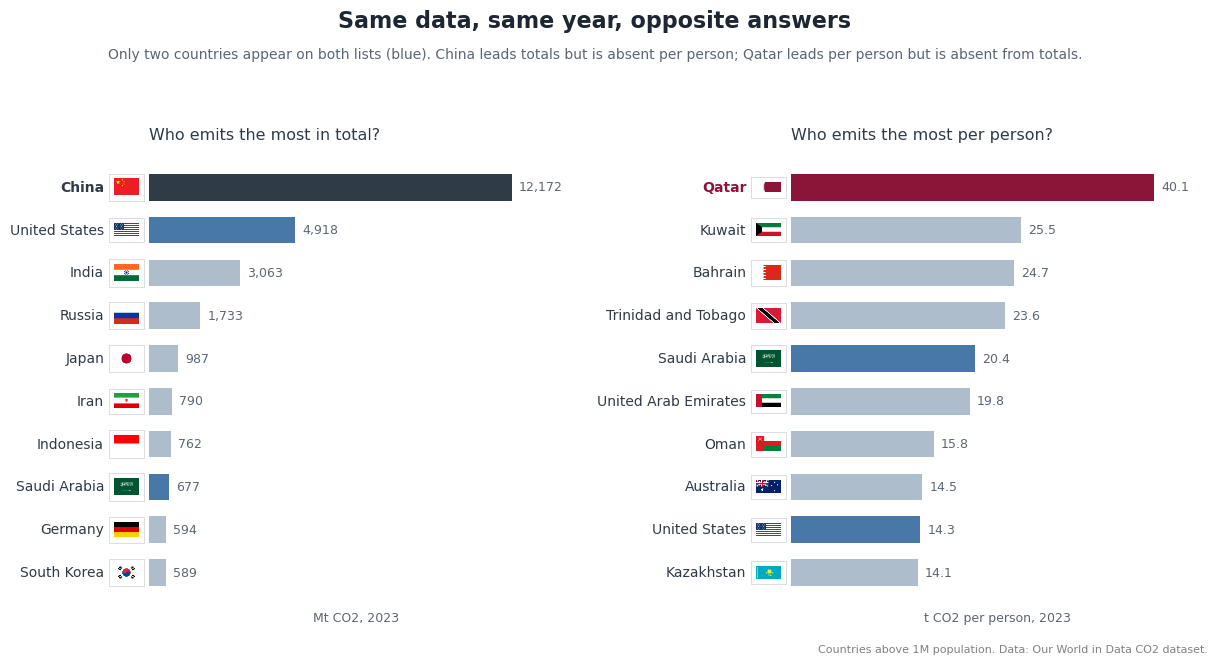

on both lists: ['Saudi Arabia', 'United States']


In [9]:
iso2 = {"CHN": "cn", "USA": "us", "IND": "in", "RUS": "ru", "JPN": "jp", "IRN": "ir",
        "IDN": "id", "SAU": "sa", "DEU": "de", "KOR": "kr", "QAT": "qa", "KWT": "kw",
        "BHR": "bh", "TTO": "tt", "ARE": "ae", "OMN": "om", "AUS": "au", "KAZ": "kz"}

snap8 = countries[(countries["year"] == 2023) & countries["co2"].notna()
                  & countries["population"].notna()].copy()
snap8 = snap8[snap8["population"] > 1e6]
top_total = snap8.nlargest(10, "co2")
top_pc = snap8.nlargest(10, "co2_per_capita")
on_both = set(top_total["country"]) & set(top_pc["country"])

QATAR_RED = "#8a1538"   # Qatar maroon
NEUTRAL = "#aebdcc"
BOTH = "#4878a8"

fig, axes = plt.subplots(1, 2, figsize=(12.5, 6.5))
fig.patch.set_facecolor("white")

def rank_panel(ax, data, value_col, unit, title, leader_color):
    d = data.iloc[::-1]  # largest at top
    colors = []
    for name in d["country"]:
        if name == d["country"].iloc[-1]:
            colors.append(leader_color)
        elif name in on_both:
            colors.append(BOTH)
        else:
            colors.append(NEUTRAL)
    bars = ax.barh(np.arange(len(d)), d[value_col], color=colors, height=0.62, zorder=3)
    ax.set_yticks([])
    vmax = d[value_col].max()
    for i, (_, row) in enumerate(d.iterrows()):
        # flag + country name to the left of the bar start
        code = iso2.get(row["iso_code"])
        flag_path = Path("../assets/flags") / f"{code}.png"
        if flag_path.exists():
            ab = AnnotationBbox(OffsetImage(plt.imread(flag_path), zoom=0.22),
                                (0, i), xybox=(-16, 0), boxcoords="offset points",
                                frameon=True, bboxprops=dict(edgecolor="#c9d1d9", linewidth=0.5),
                                annotation_clip=False)
            ax.add_artist(ab)
        bold = row["country"] == d["country"].iloc[-1]
        ax.annotate(row["country"], (0, i), xytext=(-32, 0), textcoords="offset points",
                    ha="right", va="center", fontsize=10,
                    fontweight="bold" if bold else "normal",
                    color=leader_color if bold else "#2f3b47", annotation_clip=False)
        ax.annotate(f"{row[value_col]:,.0f}" if vmax > 100 else f"{row[value_col]:.1f}",
                    (row[value_col], i), xytext=(5, 0), textcoords="offset points",
                    va="center", fontsize=9, color="#5a6673")
    ax.set_xlim(0, vmax * 1.14)
    ax.set_xticks([])
    ax.set_title(title, fontsize=11.5, pad=10, loc="left", color="#2f3b47")
    ax.set_xlabel(unit, fontsize=9, color="#5a6673")
    for s in ["top", "right", "bottom", "left"]:
        ax.spines[s].set_visible(False)

rank_panel(axes[0], top_total, "co2", "Mt CO2, 2023",
           "Who emits the most in total?", "#2f3b47")
rank_panel(axes[1], top_pc, "co2_per_capita", "t CO2 per person, 2023",
           "Who emits the most per person?", QATAR_RED)

fig.suptitle("Same data, same year, opposite answers",
             fontsize=16, fontweight="bold", x=0.5, y=1.00, color="#1c2733")
fig.text(0.5, 0.925,
         "Only two countries appear on both lists (blue). China leads totals but is absent per person; "
         "Qatar leads per person but is absent from totals.",
         ha="center", fontsize=10, color="#5a6673")
fig.text(0.99, 0.01, "Countries above 1M population. Data: Our World in Data CO2 dataset.",
         ha="right", fontsize=8, color="gray")
fig.tight_layout(rect=[0.02, 0.03, 1, 0.90])
fig.subplots_adjust(wspace=0.55)
fig.savefig(FIG_DIR / "fig8_ranking_reversal.png", dpi=150, facecolor="white",
            bbox_inches="tight")
plt.show()

print("on both lists:", sorted(on_both))

## What these eight figures argue, together

1. The variable is extremely skewed (fig 1) and concentrated (fig 2), so evaluation must be scale-aware.
2. The variable barely moves year to year (fig 3), so persistence is the honest bar to clear.
3. Feature availability, not preference, dictates the two-wave feature plan (fig 4).
4. Energy data is well populated and tightly coupled to emissions (fig 5), so it joins as features first; predicting energy itself is a later, gated extension using the same pipeline.
5. Qatar (fig 6) is the by-eye verification anchor for Session 2.
6. The denominator changes the ranking entirely (figs 7 and 8): China leads totals, Qatar leads per capita, and only two countries appear on both top-10 lists. Framing awareness is part of evaluation honesty.

## References

Our World in Data CO2 dataset repository: https://github.com/owid/co2-data

Matplotlib documentation: https://matplotlib.org/stable/

Country flag images: https://flagcdn.com (Flagpedia)
